# Natural Language Processing
## Assignment 1 - Group 17

*_Adriano Machado (up202105352), Félix Martins (up202108837), Francisco da Ana (up202108762)_*  


### Overview

This assignment applies fundamental NLP techniques to solve a text classification problem without relying on deep learning architectures.

**Workflow:**

1.  **Data Exploration:**  Dataset analysis through visualization and statistics.
2.  **Preprocessing:** Text normalization, cleaning, and feature extraction pipeline.
3.  **Feature Representation:** Sparse (TF-IDF) and dense (word embeddings) feature experimentation.
4.  **Model Selection:** Classical ML algorithm testing (Naive Bayes, Logistic Regression, SVM, etc.).
5.  **Evaluation:** Performance measurement and iterative model improvement.

### Data: Polite Guard Dataset

The [Polite Guard dataset](https://github.com/intel/polite-guard), developed by Intel, is used for **politeness classification**.

**Key Features:**

*   Specialized corpus for politeness in text.
*   **Sources:**
    *   100k synthetic samples (50k Few-Shot & 50k using Chain-of-Thought prompting).
    *   200 real-world samples from corporate training. (with personal identifiers removed)

### Annotation Categories

Four-category politeness classification:

1.  **Polite:** Courteous and respectful text with friendly tone.
2.  **Somewhat Polite:** Respectful but less warm or formal.
3.  **Neutral:** Factual, straightforward text without politeness attempts.
4.  **Impolite:** Rude, blunt, and disrespectful text.

### Data Structure

Each example includes:

*   **text:** Input text string.
*   **label:** Politeness category (polite, somewhat polite, neutral, impolite).
*   **source:** Generation model ("LMS" for real data).
*   **reasoning:** LLM rationale (for synthetic data with Chain-of-Thought prompting).

##  **Data Exploration**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import TruncatedSVD
import gensim
import re
import gc
import os
import time
from datetime import datetime
from typing import List, Dict, Tuple, Any, Optional, Union, Set

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /home/adriano/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/adriano/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/adriano/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/adriano/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /home/adriano/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/adriano/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [3]:
file_paths = {
    'train_cot': 'data/train/train_cot.csv',
    'train_few_shot': 'data/train/train_few_shot.csv',
    'val_cot': 'data/validation/val_cot.csv',
    'val_few_shot': 'data/validation/val_few_shot.csv',
    'test_cot': 'data/test/test_cot.csv',
    'test_few_shot': 'data/test/test_few_shot.csv',
    'test_LMs': 'data/test/test_lms.csv'
}

sns.set_palette("crest")

dataframes = {}
for name, path in file_paths.items():
    dataframes[name] = pd.read_csv(path)

In [4]:
table_data = []
for name, df in dataframes.items():
    shape = df.shape
    columns = ', '.join(df.columns)
    missing_values = df.isnull().sum().to_dict()
    duplicates = df.duplicated().sum()
    
    table_data.append({
        'Dataset': name,
        'Rows': f"{shape[0]}",
        'Duplicates': duplicates,
        'Missing Values': str(missing_values),
    })

table_df = pd.DataFrame(table_data)
table_df


,Dataset,Rows,Duplicates,Missing Values
0,train_cot,40000,0,"{'text': 0, 'label': 0, 'source': 0, 'reasonin..."
1,train_few_shot,40000,0,"{'text': 0, 'label': 0, 'source': 0, 'reasonin..."
2,val_cot,5000,0,"{'text': 0, 'label': 0, 'source': 0, 'reasonin..."
3,val_few_shot,5000,0,"{'text': 0, 'label': 0, 'source': 0, 'reasonin..."
4,test_cot,5000,0,"{'text': 0, 'label': 0, 'source': 0, 'reasonin..."
5,test_few_shot,5000,0,"{'text': 0, 'label': 0, 'source': 0, 'reasonin..."
6,test_LMs,200,0,"{'text': 0, 'label': 0, 'source': 0, 'reasonin..."


As we can see, there's no duplicates and no missing values in our dataset's.

There's about 80000(80%) instances of training, 10000(10%) instances of validation and 10000(10%) instances of test (plus 200 real world examples)

In order to better analyze the datasets, we'll merge the training, validation and test datasets.

In [5]:
all_synthetic = pd.concat([dataframes['train_cot'], dataframes['train_few_shot'], dataframes['val_cot'], dataframes['val_few_shot'], dataframes['test_cot'], dataframes['test_few_shot']])

combined_dataframes = {
    'Synthetic data': all_synthetic,
    'Real data': dataframes['test_LMs']
}

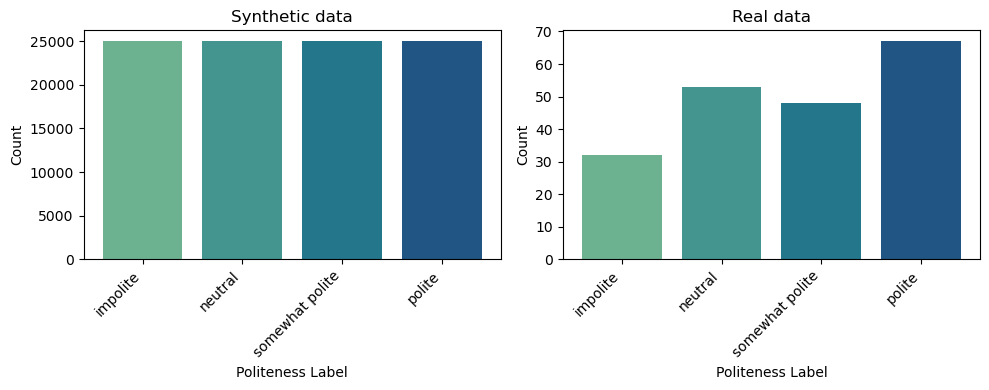

In [6]:
label_order = ['impolite', 'neutral', 'somewhat polite', 'polite']

plt.figure(figsize=(10, 4))
n_datasets = len(combined_dataframes)
for i, (name, df) in enumerate(combined_dataframes.items(), 1):
    if 'label' in df.columns:
        label_counts = Counter(df['label'].astype(str))
        labels = [l for l in label_order if l in label_counts]  
        counts = [label_counts[l] for l in labels if l in label_counts]
        
        plt.subplot(1, n_datasets, i)
        
        colors = sns.color_palette("crest", n_colors=len(labels))
        plt.bar(labels, counts, color=colors)
        
        plt.title(f'{name}')
        plt.xlabel('Politeness Label')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
    
plt.tight_layout()
plt.show()

The synthetic datasets show similar distributions across politeness labels. In contrast, the real dataset is slightly biased, with a higher proportion of "polite" and "neutral" labels compared to "impolite" and "somewhat polite" ones.

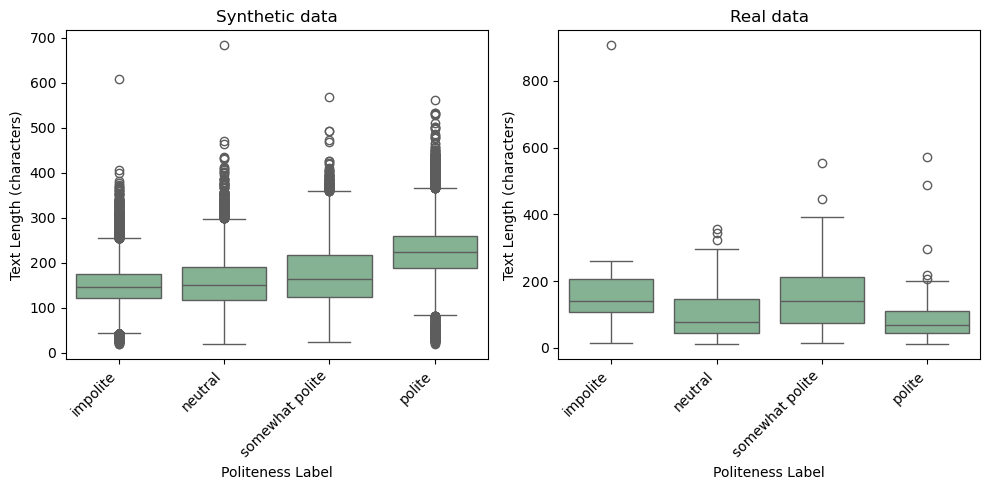

In [7]:
plt.figure(figsize=(10, 5))
for i, (name, df) in enumerate(combined_dataframes.items(), 1):
    if 'label' in df.columns and 'text' in df.columns:
        text_lengths = df['text'].astype(str).fillna('').str.len()
        
        plt.subplot(1, n_datasets, i)
        sns.boxplot(data=df, x='label', y=text_lengths, order=label_order)
        plt.title(f'{name}')
        plt.xlabel('Politeness Label')
        plt.ylabel('Text Length (characters)')
        plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

The synthetic datasets exhibit a tendency where longer texts are associated with higher politeness levels. This pattern, however, is not observed in the real test set, indicating potential biases or artificial correlations inherent in the synthetic data generation.

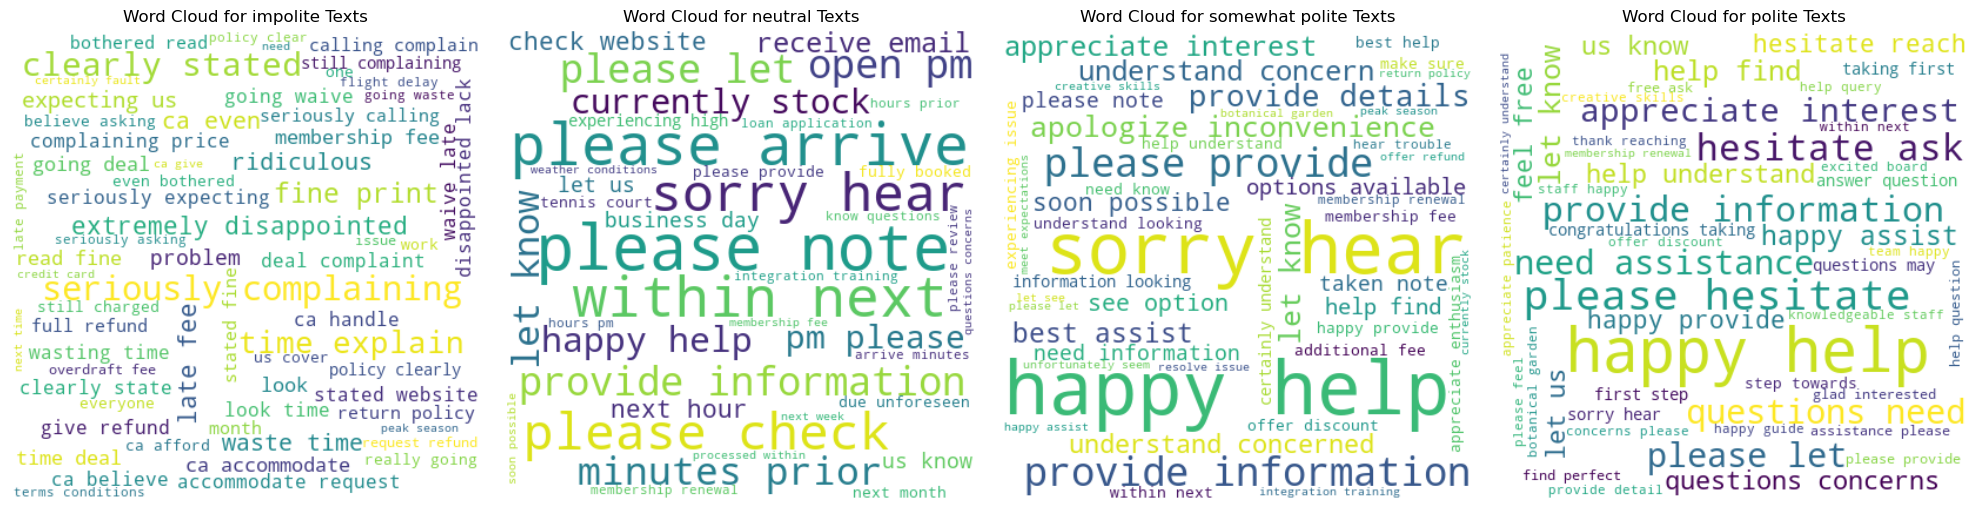

In [8]:
def generate_word_clouds(label_texts, label_order):
    num_labels = len(label_order)
    fig, axes = plt.subplots(1, num_labels, figsize=(5 * num_labels, 5)) 
    
    if num_labels == 1: 
        axes = [axes]

    for ax, label in zip(axes, label_order):
        if label_texts[label]: 
            stop_words = set(stopwords.words('english'))
            word_tokens = word_tokenize(' '.join(label_texts[label]))
            filtered_words = [word.lower() for word in word_tokens if word.lower() not in stop_words and word.isalnum()]
            
            wordcloud = WordCloud(width=400, height=400, background_color='white', min_font_size=10).generate(' '.join(filtered_words))

            ax.imshow(wordcloud, interpolation='bilinear')
            ax.set_title(f'Word Cloud for {label} Texts')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

label_texts = {label: [] for label in label_order}
for name, df in combined_dataframes.items():
    if 'label' in df.columns and 'text' in df.columns:
        for label in label_order:
            label_texts[label].extend(df[df['label'].astype(str) == label]['text'].dropna().tolist())


generate_word_clouds(label_texts, label_order)

Impolite language conveys frustration through words like "seriously" and "ridiculous." Neutral language adopts a factual and instructive tone, using terms like "please" and "note." Somewhat polite language attempts to mitigate negativity with words of apology and empathy, such as "sorry" and "hear." Polite language is marked by expressions of helpfulness and respect, including words like "happy" and "assistance."

In [9]:
def get_top_ngrams(texts, n=1, top_k=20):
    stop_words = set(stopwords.words('english'))
    all_ngrams = []
    
    for text in texts:
        tokens = [token.lower() for token in word_tokenize(text) 
                 if token.isalnum() and token.lower() not in stop_words]
        
        text_ngrams = list(ngrams(tokens, n))
        all_ngrams.extend(text_ngrams)
    
    ngram_freq = Counter(all_ngrams)
    
    return ngram_freq.most_common(top_k)

In [10]:
def plot_top_ngrams(label_texts, label_order, n=1, top_k=15):
    fig, axes = plt.subplots(1, len(label_order), figsize=(6 * len(label_order), 6))
    
    for i, label in enumerate(label_order):
        ax = axes[i]
        if not label_texts[label]:
            ax.text(0.5, 0.5, f"No data for {label}", ha='center', va='center')
            ax.set_title(f"Top {top_k} {n}-grams for {label}")
            ax.axis('off')
            continue
            
        top_ngrams = get_top_ngrams(label_texts[label], n, top_k)
        
        if n > 1:
            labels = [' '.join(ng[0]) for ng in top_ngrams]
        else:
            labels = [ng[0][0] for ng in top_ngrams]
            
        values = [ng[1] for ng in top_ngrams]
        
        bars = ax.barh(range(len(labels)), values, color=sns.color_palette("crest", n_colors=1)[0])
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels)
        ax.invert_yaxis() 
        ax.set_title(f"Top {top_k} {n}-grams for {label}")
        
        for bar in bars:
            width = bar.get_width()
            ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f"{int(width)}", 
                    ha='left', va='center')
    
    plt.tight_layout()
    return fig

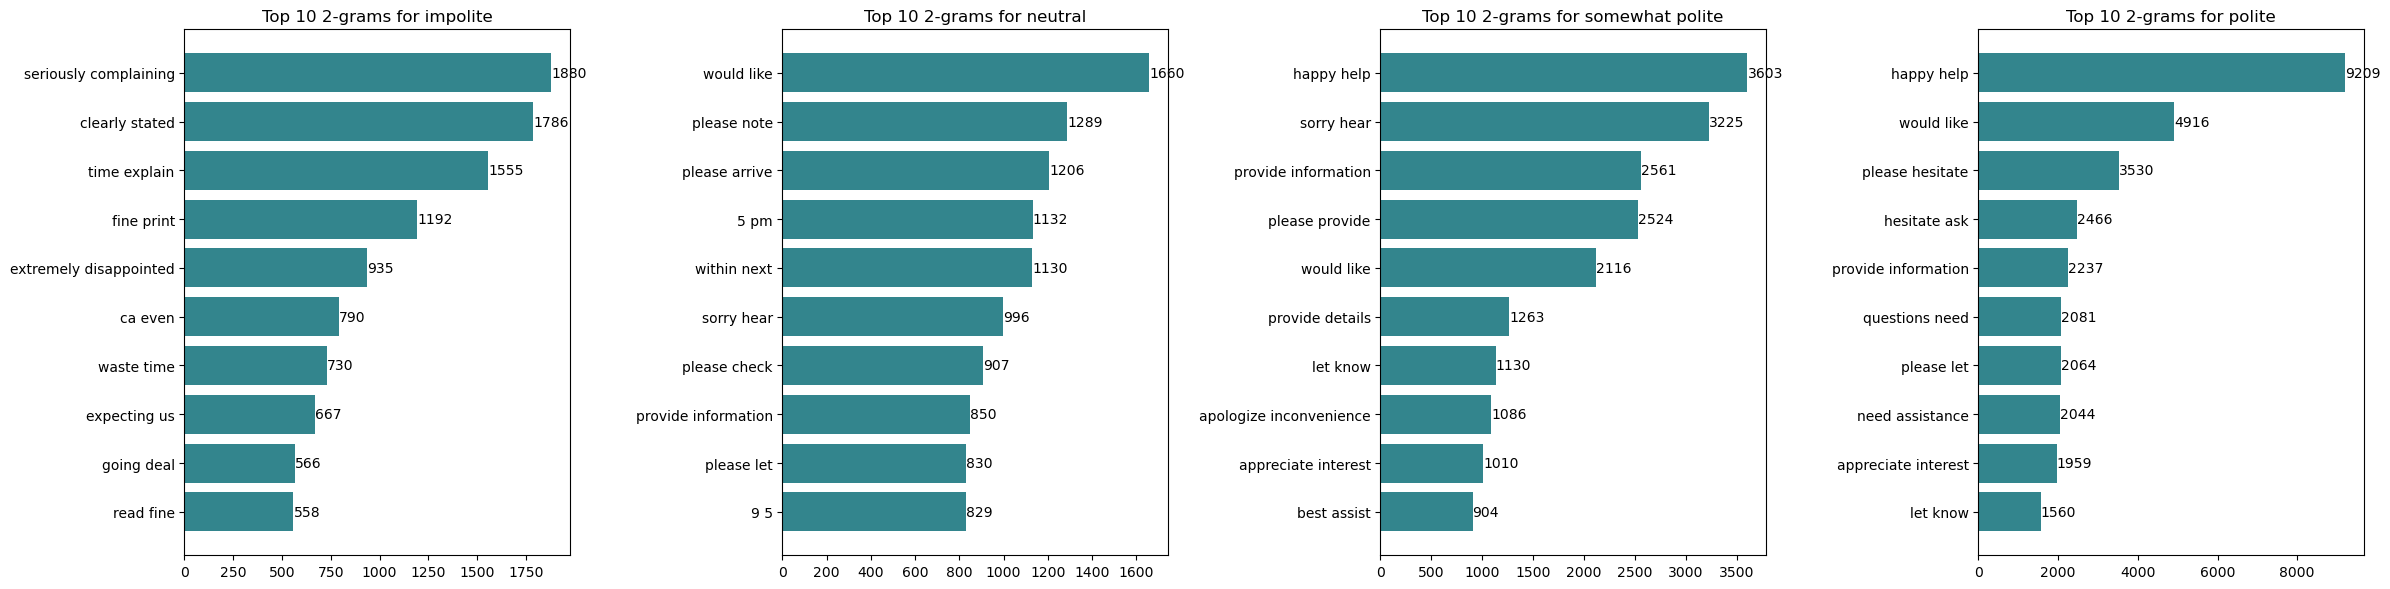

In [11]:
unigram_fig = plot_top_ngrams(label_texts, label_order, n=2, top_k=10)
plt.show()

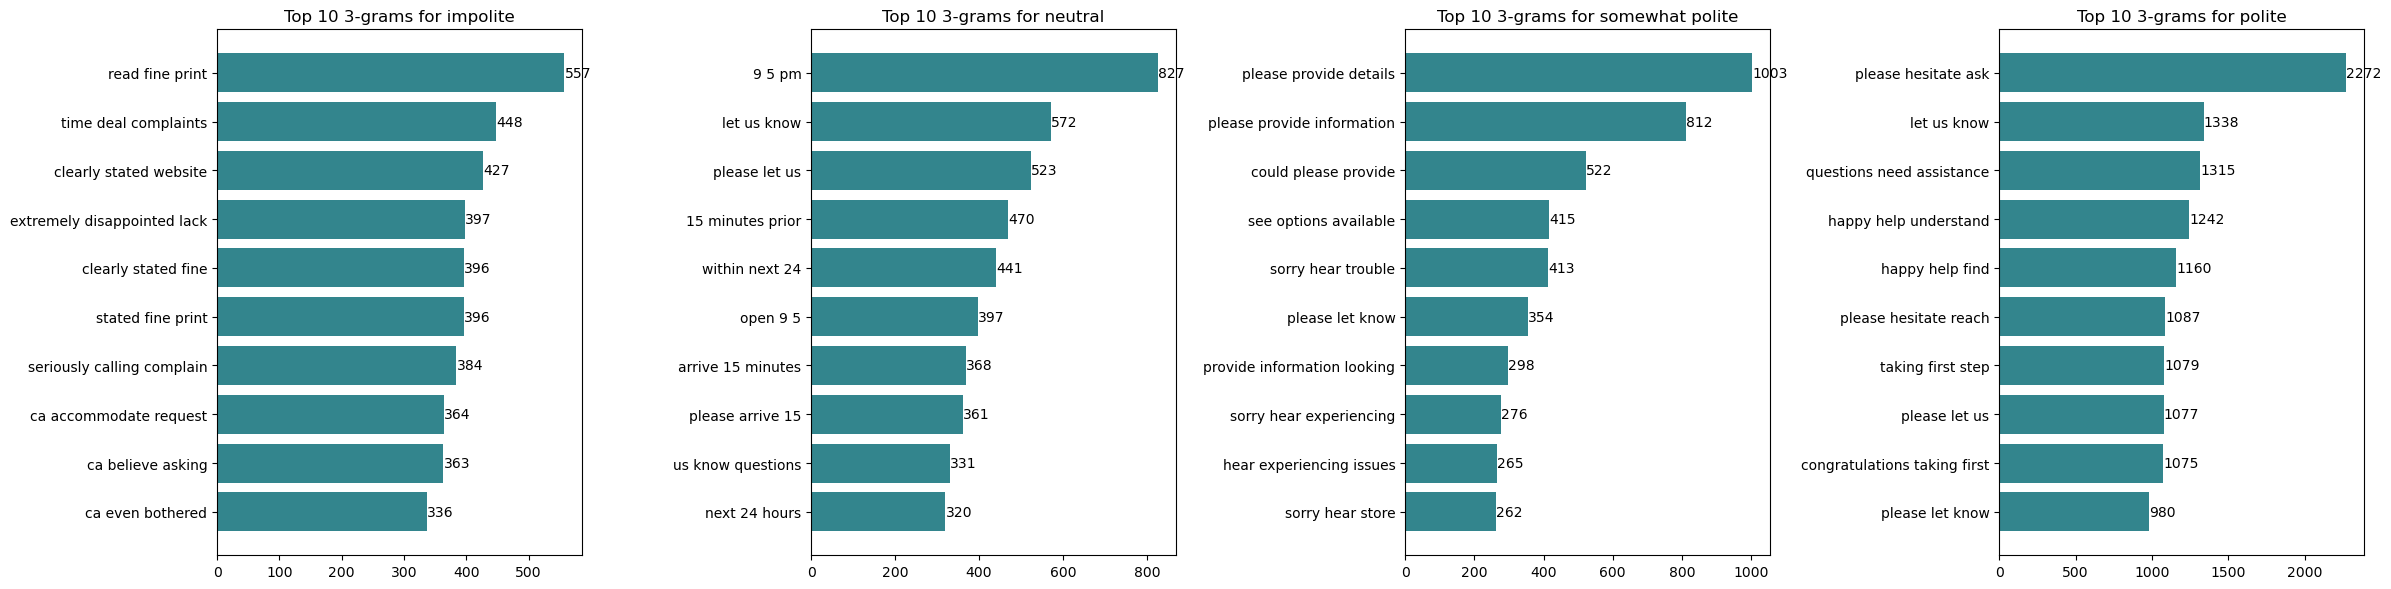

In [12]:
unigram_fig = plot_top_ngrams(label_texts, label_order, n=3, top_k=10)
plt.show()

Analyzing the 3-gram we notice some linguistic patterns: 

- "impolite" texts show frustration (e.g., "read fine print", "time deal complaints")
- "neutral" are more factual (e.g., "9:5 pm")
- while "somewhat polite" (e.g., "please provide details") and "polite" (e.g., "please hesitate ask") texts reflect increasing courtesy

Let's now perform sentiment analysis on the dataset.

In [13]:
def analyze_sentiment_subjectivity_for_plotting(df, label_order):
    sentiment_data_plot = {}
    for label in label_order:
        label_df = df[df['label'].astype(str) == label]['text'].dropna()
        polarities = []
        subjectivities = []
        for text in label_df:
            blob = TextBlob(text)
            polarities.append(blob.sentiment.polarity)
            subjectivities.append(blob.sentiment.subjectivity)
        sentiment_data_plot[label] = {'polarity': polarities, 'subjectivity': subjectivities}
    return sentiment_data_plot


In [14]:
sentiment_plot_results = {}
for name, df in combined_dataframes.items():
    if 'label' in df.columns and 'text' in df.columns:
        print(f"\nProcessing: {name}")
        sentiment_plot_results[name] = analyze_sentiment_subjectivity_for_plotting(df, label_order)


Processing: Synthetic data



Processing: Real data


In [15]:
def visualize_sentiment_by_type(sentiment_plot_results, label_order, plot_type):
    """
    plot_type (str): 'polarity' or 'subjectivity' to specify which metric to plot
    """
    if plot_type not in ['polarity', 'subjectivity']:
        raise ValueError("plot_type must be either 'polarity' or 'subjectivity'")
        
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    if plot_type == 'polarity':
        plot_title = 'Sentiment Polarity by Politeness Level'
        ylabel = 'Sentiment Polarity (-1 to 1)'
        annotation = 'Polarity: -1 (negative) to 1 (positive)'
    else:  
        plot_title = 'Subjectivity by Politeness Level'
        ylabel = 'Subjectivity (0 to 1)'
        annotation = 'Subjectivity: 0 (objective) to 1 (subjective)'
    

    datasets = list(sentiment_plot_results.keys())
    colors = sns.color_palette("crest", n_colors=len(label_order))
    
    for d, dataset in enumerate(datasets):
        data_to_plot = []
        for j, label in enumerate(label_order):
            if label in sentiment_plot_results[dataset]:
                values = sentiment_plot_results[dataset][label][plot_type]
                if values:
                    data_to_plot.append(values)
                else:
                    data_to_plot.append([])
            else:
                data_to_plot.append([])
        
        bp = axs[d].boxplot(data_to_plot, patch_artist=True, tick_labels=label_order)
        
        for j, box in enumerate(bp['boxes']):
            box.set(facecolor=colors[j])
        
        axs[d].set_title(f"{plot_title} - {dataset}", fontsize=10)
        axs[d].set_ylabel(ylabel, fontsize=9)
        axs[d].set_xticklabels(label_order, rotation=45, ha='right', fontsize=8)
        

    fig.text(0.5, 0.01, annotation, ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)
    plt.show()


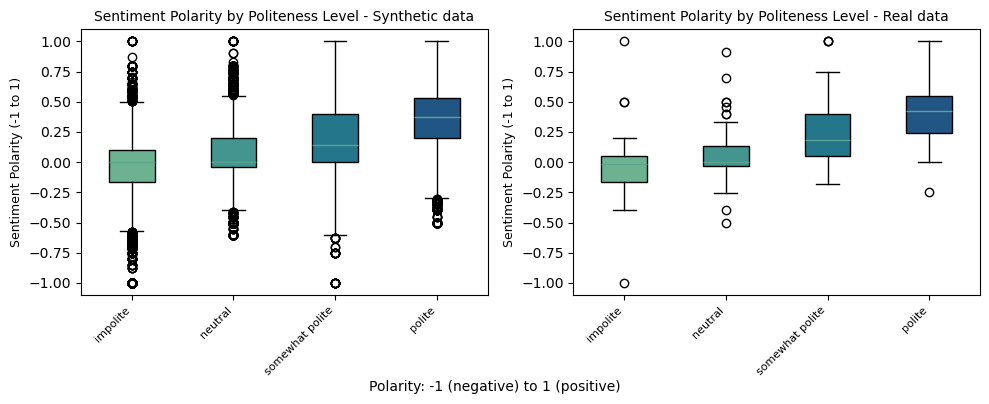

In [16]:
visualize_sentiment_by_type(sentiment_plot_results, label_order, 'polarity')

As we can see the sentiment polarity is directly related to the politeness label, with "polite" texts being more positive and "impolite" texts being more negative.

This relationship is similar in synthetic and real datasets.

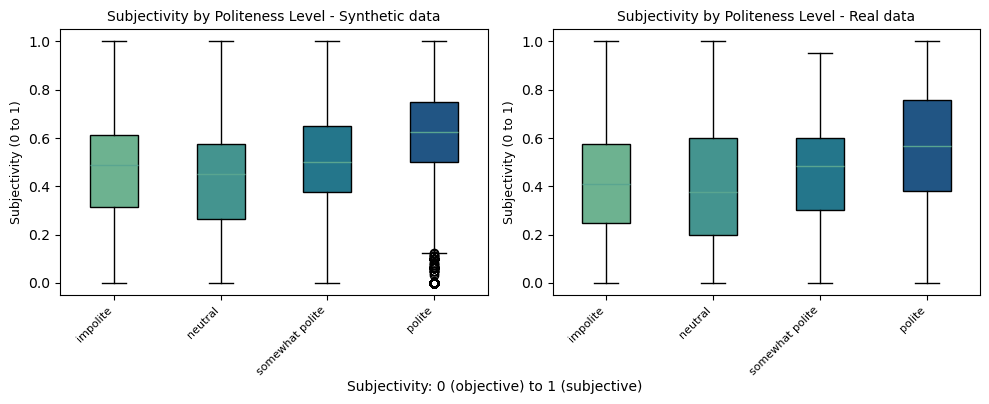

In [17]:
visualize_sentiment_by_type(sentiment_plot_results, label_order, 'subjectivity')

In terms of subjectivity the relationship is less clear, but polite texts tend to be more subjective than impolite ones. 

## **Pre-processing Pipeline**


The **TextPreprocessor** class is designed to handle text preprocessing steps. It includes methods for:

*   **Lemmatization:** Reducing words to their base or dictionary form.
*   **Stopword Removal:**  Optionally removing common English stopwords.
*   **Handling Digits and Special Characters:** Optionally including or removing digits and special characters during preprocessing.
*   **POS Tagging:** Part-of-Speech tagging to improve lemmatization accuracy.

In [18]:
class TextPreprocessor:
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stopwords = set(stopwords.words('english'))
        
    def get_wordnet_pos(self, nltk_tag: str) -> str:
        """
        Convert NLTK POS tags to WordNet POS tags.
        """
        tag_to_wordnet = {
            'J': wordnet.ADJ,
            'V': wordnet.VERB,
            'N': wordnet.NOUN,
            'R': wordnet.ADV
        }
        return tag_to_wordnet.get(nltk_tag[0], wordnet.NOUN)
    
    def preprocess_text(self, text: str, include_sw: bool, include_digits: bool) -> str:
        """
        Preprocess text data for NLP tasks.
        
        Args:
            text: Raw text to preprocess
            include_sw: Whether to include stopwords
            include_digits: Whether to include digits
            
        Returns:
            Preprocessed text
        """
        if not text or pd.isna(text):
            return ""
            
        if not include_digits:
            text = re.sub('[^a-zA-Z]', ' ', text)
        else:
            text = re.sub('[^a-zA-Z0-9]', ' ', text)
            
        text = text.lower()

        words = word_tokenize(text)
        tagged_words = pos_tag(words)
        
        lemmatized_words = [
            self.lemmatizer.lemmatize(word, self.get_wordnet_pos(pos_tag)) 
            for word, pos_tag in tagged_words 
            if word not in self.stopwords or include_sw
        ]
        
        return ' '.join(lemmatized_words)

Now, let's define the **DataLoader** class to load and preprocess the dataset. In order to do so efficiently, we'll implement a batch processing method that reads and preprocesses data in chunks.


In [19]:
class DataLoader:
    def __init__(self, file_paths: Dict[str, str], preprocessor: TextPreprocessor):
        self.file_paths = file_paths
        self.preprocessor = preprocessor
        
    def process_in_batches(self, 
                          paths: List[str], 
                          feature: str, 
                          target: str, 
                          include_sw: bool, 
                          include_digits: bool, 
                          batch_size: int = 1000) -> Tuple[List[str], List[int]]:
        processed_texts = []
        labels = []
        
        for path in paths:
            print(f"Processing file: {path}")
            for chunk in pd.read_csv(path, chunksize=batch_size):
                chunk_texts = chunk[feature].fillna('').apply(
                    lambda x: self.preprocessor.preprocess_text(x, include_sw, include_digits)
                )
                processed_texts.extend(chunk_texts.tolist())
                labels.extend(chunk[target].tolist())
                
                del chunk_texts
                gc.collect()
        
        return processed_texts, labels

## **Feature Representation**

The `WordEmbeddingsModel` class manages the training and usage of Word2Vec word embeddings.

As arguments, the class constructor accepts:
*    **vector_size**: Dimensionality of word vectors
*    **window**: Maximum distance between current and predicted word
*    **min_count**: Ignores all words with total frequency lower than this
*    **workers**: Number of CPU cores to use
*    **pretrained_path**: Path to pretrained word vectors (if using pretrained model)

In [20]:
class WordEmbeddingsModel:
    """
    Handles word embedding model training and feature extraction.
    """
    def __init__(self, vector_size: int, window: int, min_count: int, workers: int, sg: int, include_sw: bool, include_digits: bool):
        self.save_dir = "embeddings"
        os.makedirs(self.save_dir, exist_ok=True)

        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.workers = workers
        self.sg = sg
        self.include_sw = include_sw
        self.include_digits = include_digits

        self.wv = None
        self.get_saved_model_if_exists()

    def is_trained(self):
        return self.wv is not None

    def get_save_path(self):
        sw_flag = "with_sw" if self.include_sw else "no_sw"
        model_type = "cbow" if self.sg == 0 else "skipgram"
        digits_flag = "with_digits" if self.include_digits else "no_digits"

        filename = f"word2vec_{model_type}_v{self.vector_size}_w{self.window}_min{self.min_count}_{sw_flag}_{digits_flag}.kv"
        return os.path.join(self.save_dir, filename)

    def get_saved_model_if_exists(self):
        if os.path.exists(self.get_save_path()):
            print(f"Loading trained embeddings from {self.get_save_path()}")
            self.wv = gensim.models.KeyedVectors.load(self.get_save_path())

    def save_model(self):
        if self.wv is not None:
            self.wv.save(self.get_save_path())
            print(f"Saved word embeddings to {self.get_save_path()}")
        else:
            print("Warning: Word embeddings are not trained yet, nothing to save.")

    def train(self, texts: List[str]):
        """
        Train a Word2Vec model on tokenized texts.

        Args:
            tokenized_texts: List of tokenized documents
        """
        print("Training Word2Vec model...")
        tokenized_texts = [text.split() for text in texts]
        self.model = gensim.models.Word2Vec(
            sentences=tokenized_texts,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=self.workers,
            sg=self.sg,
        )
        self.wv = self.model.wv
        self.save_model()

    def get_document_vector(self, text: str) -> np.ndarray:
        """
        Compute document vector by averaging word vectors.
        """
        tokens = text.split()
        if not tokens:
            return np.zeros(self.vector_size)

        vectors = []
        for token in tokens:
            try:
                vectors.append(self.wv.get_vector(token))
            except KeyError:
                continue

        if not vectors:
            return np.zeros(self.vector_size)

        return np.mean(vectors, axis=0)

    def transform_documents(self, docs: List[str]) -> np.ndarray:
        doc_vectors = np.vstack([self.get_document_vector(doc) for doc in docs])
        return doc_vectors

The `FeatureExtractor` class is a versatile component for extracting features from text data. It supports different vectorization techniques:

*   **Bag of Words (BoW):**  Creates a frequency count of words. Supports different n-gram ranges.
*   **TF-IDF (Term Frequency-Inverse Document Frequency):**  Weights word frequencies by their inverse document frequency, highlighting important words in the corpus.
*   **Word Embeddings (Word2Vec):** Uses the `WordEmbeddingsModel` to generate dense vector representations of documents.

The class acts as an abstraction layer, allowing easy switching between different feature extraction methods by specifying the `extractor_type` during initialization.


In [21]:
class FeatureExtractor:
    """
    Handles feature extraction from text data using various vectorization methods.
    """
    def __init__(self, extractor_type: str, params: Dict[str, Any], reuse_configuration: dict[str, Any] = None):
        """
        Initialize the feature extractor.

        Args:
            extractor_type: Type of extractor (BoW, TF-IDF, etc.)
            params: Parameters for the extractor
            reuse_configuration: Configuration for reusing an already trained model (or saving one)
        """
        self.extractor_type = extractor_type
        self.vectorizer = None

        if extractor_type == "word2vec" and reuse_configuration is None:
            raise ValueError("Must provide reuse configuration for word2vec model")

        if extractor_type.startswith("BoW"):
            self.vectorizer = CountVectorizer(**params)
        elif extractor_type == "TF-IDF":
            self.vectorizer = TfidfVectorizer(**params)
        elif extractor_type == "word2vec":
            self.vectorizer = WordEmbeddingsModel(**params, **reuse_configuration)
        else:
            raise ValueError(f"Unsupported extractor type: {extractor_type}")

    def extract_features(self, texts: List[str], train: bool = False):
        """
        Extract features while keeping matrices sparse.

        Args:
            texts: List of processed text documents
            train: Whether this is training data (fit_transform) or not (transform)

        Returns:
            Sparse feature matrix
        """
        if self.extractor_type == "word2vec":
            if train and not self.vectorizer.is_trained():
                self.vectorizer.train(texts) 
            return self.vectorizer.transform_documents(texts)
        else:
            if train:
                return self.vectorizer.fit_transform(texts)
            else:
                return self.vectorizer.transform(texts)

The `DimensionalityReducer` class handles dimensionality reduction using techniques like Truncated Singular Value Decomposition (SVD).

*   **SVD for Sparse Data:** Uses TruncatedSVD, which is efficient for sparse matrices often generated in NLP feature extraction.
*   **Reduces Feature Dimensions:** Reduces the number of features to a specified `n_components`, potentially improving model performance and reducing computational cost.
*   **Abstraction for Reducers:** Can be extended to include other dimensionality reduction methods in the future.


In [22]:
class DimensionalityReducer:
    """
    Handles dimensionality reduction for feature matrices.
    """
    def __init__(self, method: str = "SVD", n_components: int = 200):
        self.method = method
        self.n_components = n_components

        if method == "SVD":
            self.reducer = TruncatedSVD(n_components=n_components, random_state=42)
        else:
            raise ValueError(f"Unsupported dimensionality reduction method: {method}")

    def reduce_dimensions(self, X, train: bool = False):
        if train:
            return self.reducer.fit_transform(X)
        else:
            return self.reducer.transform(X)

The `FeatureScaler` class is responsible for scaling feature matrices to a specific range or distribution.

*   **Standard Scaling:** Uses `StandardScaler` to standardize features by removing the mean and scaling to unit variance.
*   **Min-Max Scaling:** Uses `MinMaxScaler` to scale features to a range between 0 and 1, useful for algorithms that benefit from normalized input, or when dealing with non-negative data after dimensionality reduction for models like Multinomial Naive Bayes.


In [23]:
class FeatureScaler:
    """
    Handles scaling of feature matrices.
    """
    def __init__(self, method: str = "standard", with_mean: bool = True, requires_non_negative: bool = False):
        self.method = method
        self.with_mean = with_mean

        if requires_non_negative:
            self.scaler = MinMaxScaler()
        elif method == "standard":
            self.scaler = StandardScaler(with_mean=with_mean)
        else:
            raise ValueError(f"Unsupported scaling method: {method}")

    def scale_features(self, X, train: bool = False):
        if train:
            return self.scaler.fit_transform(X)
        else:
            return self.scaler.transform(X)


## **Model Train and Selection**

The `ModelTrainer` class encapsulates the training and hyperparameter tuning of machine learning models.

*   **Supports Multiple Models:** Currently supports Support Vector Machines (SVM), Naive Bayes (NB), and Logistic Regression (LR).
*   **Hyperparameter Tuning:** Implements grid search based hyperparameter tuning using `ParameterGrid` from scikit-learn.
*   **Training and Evaluation:** Provides methods to train models (`train_model()`) and evaluate their performance (`evaluate_model()`).
*   **Returns Best Model and Parameters:**  `tune_hyperparameters()` returns the best hyperparameters found during grid search and the corresponding validation score.

In [24]:
class ModelTrainer:
    """
    Handles model training and hyperparameter tuning.
    """
    def __init__(self, model_type: str, hyperparameters: Dict[str, List[Any]] = None):
        self.model_type = model_type
        self.hyperparameters = hyperparameters or {}

        if model_type == "SVM":
            self.model = SVC(random_state=42)
        elif model_type == "NB":
            self.model = MultinomialNB()
        elif model_type == "LR":
            self.model = LogisticRegression(random_state=42, n_jobs=-1)
        else:
            raise ValueError(f"Unsupported model type: {model_type}")

    def train_model(self, X_train, y_train):
        start_time = time.time()
        self.model.fit(X_train, y_train)
        end_time = time.time()
        training_time = end_time - start_time

        return self.model, training_time

    def evaluate_model(self, X_val, y_val):
        """
        Evaluate model on validation data, returning accuracy score.
        """
        y_pred = self.model.predict(X_val)
        return accuracy_score(y_val, y_pred)

    def tune_hyperparameters(self, X_train, y_train, X_val, y_val):
        """
        Tune hyperparameters using grid search.

        Args:
            X_train: Training feature matrix
            y_train: Training labels
            X_val: Validation feature matrix
            y_val: Validation labels

        Returns:
            Best parameters, validation score, and training time
        """
        best_score = 0
        best_params = None
        best_training_time = 0

        if not self.hyperparameters or self.model_type == "SVM":
            model, training_time = self.train_model(X_train, y_train)
            score = self.evaluate_model(X_val, y_val)
            return {} if self.model_type == "SVM" else self.model.get_params(), score, training_time

        for params in ParameterGrid(self.hyperparameters):
            self.model.set_params(**params)

            model, training_time = self.train_model(X_train, y_train)
            score = self.evaluate_model(X_val, y_val)

            print(f"Score: {score:.4f}, Time: {training_time:.2f}s for {params}")
            if score > best_score:
                best_score = score
                best_params = params
                best_training_time = training_time

        return best_params, best_score, best_training_time


The `ExperimentTracker` class is designed to keep track of experiment results and configurations.

In [25]:
class ExperimentTracker:
    """
    Handles tracking and saving of experiment results.
    """
    def __init__(self, filename: str):
        self.filename = filename
        self.results = []
        self.completed_configs = set()

        if os.path.exists(filename):
            try:
                existing_df = pd.read_csv(filename)
                self.results = existing_df.to_dict('records')

                for result in self.results:
                    config_key = (
                        result['include_digits'],
                        result['feature_extraction'],
                        result['dim'],
                        result['model']
                    )
                    self.completed_configs.add(config_key)

                print(f"Loaded {len(self.results)} existing results from {filename}")
            except Exception as e:
                print(f"Error loading existing results: {e}")

    def is_completed(self, config_key: Tuple) -> bool:
        return config_key in self.completed_configs

    def add_result(self, result: Dict[str, Any]):
        self.results.append(result)

        config_key = (
            result['include_digits'],
            result['feature_extraction'],
            result['dim'],
            result['model']
        )
        self.completed_configs.add(config_key)

        self.save_results()

    def save_results(self):
        pd.DataFrame(self.results).to_csv(self.filename, index=False)
        print(f"Results saved to {self.filename}")

    def get_best_config(self):
        results_df = pd.DataFrame(self.results)
        best_config = results_df.loc[results_df['val_score'].idxmax()]
        return best_config

The `ExperimentRunner` class orchestrates the entire experiment process. It combines all the previously defined classes to execute and manage NLP experiments systematically.

*   **End-to-End Experiment Management:** Manages data loading, preprocessing, feature extraction, dimensionality reduction, scaling, model training, hyperparameter tuning, and result tracking.
*   **Experiment Configuration:**  Sets up experiment configurations through the `setup_experiment()` method, allowing for systematic testing of different parameter combinations.
*   **Experiment Execution Loop:**  The `run_experiment()` method iterates through all defined configurations, runs each experiment, and logs the results using the `ExperimentTracker`.
*   **Best Configuration Identification:** After running all experiments, it identifies and prints the best configuration based on validation performance.

In [26]:
class ExperimentRunner:
    """
    Main class that orchestrates the entire NLP pipeline experiment.
    """
    def __init__(self, file_paths: Dict[str, str], results_filename: str):
        self.file_paths = file_paths
        self.preprocessor = TextPreprocessor()
        self.data_loader = DataLoader(file_paths, self.preprocessor)
        self.tracker = ExperimentTracker(results_filename)

    def setup_experiment(self,
                         include_digits_options: Tuple[bool, ...],
                         feature_extraction_configs: Tuple[Dict[str, Any], ...],
                         dimension_options: Tuple[int, ...],
                         model_configs: Tuple[Dict[str, Any], ...]):
        """
        Set up experiment configurations.

        Args:
            include_digits_options: Options for including digits
            feature_extraction_configs: Configurations for feature extraction
            dimension_options: Options for dimensionality reduction
            model_configs: Configurations for models
        """
        self.include_digits_options = include_digits_options
        self.feature_extraction_configs = feature_extraction_configs
        self.dimension_options = dimension_options
        self.model_configs = model_configs

    def run_experiment(self, feature: str = 'text', target: str = 'label'):
        """
        Run the experiment with all configurations.

        Args:
            feature: Column name containing text data
            target: Column name containing labels
        """
        train_files = [self.file_paths['train_cot'], self.file_paths['train_few_shot']]
        val_files = [self.file_paths['val_cot'], self.file_paths['val_few_shot']]

        # Loop through all experiment combinations
        for include_digit in self.include_digits_options:
            print(f"\n{'='*50}")
            print(f"Processing with include_digit={include_digit}")

            processed_data = {}

            for feature_extraction in self.feature_extraction_configs:
                print(f"\n{'-'*50}")
                print(f"Feature extraction: {feature_extraction['name']}")

                include_sw = feature_extraction['include_sw']

                for dim in self.dimension_options:
                    dim_name = "full" if dim == -1 else f"SVD_{dim}"

                    if feature_extraction['name'] == "word2vec" and dim_name != "full":
                        print(f"Skipping dimensionality reduction for word2vec (already low-dimensional)")
                        continue

                    for model_config in self.model_configs:
                        config_key = (
                            include_digit,
                            feature_extraction['name'],
                            dim_name,
                            model_config['name']
                        )

                        if self.tracker.is_completed(config_key):
                            print(f"Skipping already completed configuration: {config_key}")
                            continue

                        print(f"\n{'-'*30}")
                        print(f"Model: {model_config['name']}")

                        try:
                            # Run this specific experiment configuration
                            self._run_single_experiment(
                                include_digit, include_sw, feature_extraction, dim, dim_name,
                                model_config, processed_data, train_files, val_files,
                                feature, target
                            )
                        except Exception as e:
                            print(f"Error in experiment: {e}")
                            continue

        best_config = self.tracker.get_best_config()
        print("\nBest configuration by validation score:")
        print(best_config)

    def _run_single_experiment(self,
                              include_digit: bool,
                              include_sw: bool,
                              feature_extraction: Dict[str, Any],
                              dim: int,
                              dim_name: str,
                              model_config: Dict[str, Any],
                              processed_data: Dict[str, Any],
                              train_files: List[str],
                              val_files: List[str],
                              feature: str,
                              target: str):
        """
        Run a single experiment configuration.

        Args:
            include_digit: Whether to include digits
            include_sw: Whether to include stopwords
            feature_extraction: Configuration for feature extraction
            dim: Dimension for dimensionality reduction
            dim_name: Name for dimension
            model_config: Configuration for model
            processed_data: Cached processed data
            train_files: Training files
            val_files: Validation files
            feature: Column name containing text data
            target: Column name containing labels
        """
        # Process data if not already processed for this include_digit setting
        data_key = f"data_{include_digit}_{include_sw}"
        if data_key not in processed_data:
            print(f">> Processing data with include_digits={include_digit}, include_sw={include_sw}")

            train_texts, train_labels = self.data_loader.process_in_batches(
                train_files, feature, target, include_sw=include_sw, include_digits=include_digit
            )

            val_texts, val_labels = self.data_loader.process_in_batches(
                val_files, feature, target, include_sw=include_sw, include_digits=include_digit
            )

            processed_data[data_key] = {
                'train_texts': train_texts,
                'train_labels': train_labels,
                'val_texts': val_texts,
                'val_labels': val_labels
            }
        else:
            cached_data = processed_data[data_key]
            train_texts = cached_data['train_texts']
            train_labels = cached_data['train_labels']
            val_texts = cached_data['val_texts']
            val_labels = cached_data['val_labels']

        feature_extractor = FeatureExtractor(
            feature_extraction['name'],
            feature_extraction['params'],
            reuse_configuration = (
                {"include_digits": include_digit, "include_sw": include_sw}
                if feature_extraction['name'] == "word2vec"
                else None
            ),
        )

        print(">> Extracting features for training data")
        X_train = feature_extractor.extract_features(train_texts, train=True)
        print(f"Training data shape: {X_train.shape}")

        print(">> Extracting features for validation data")
        X_val = feature_extractor.extract_features(val_texts)
        print(f"Validation data shape: {X_val.shape}")

        if dim == -1:
            X_train_red = X_train
            X_val_red = X_val
        else:
            print(f">> Applying dimensionality reduction with {dim} components")

            try:
                # Use TruncatedSVD for sparse matrices
                dim_reducer = DimensionalityReducer(method="SVD", n_components=dim)

                X_train_red = dim_reducer.reduce_dimensions(X_train, train=True)
                X_val_red = dim_reducer.reduce_dimensions(X_val)

                gc.collect()
            except MemoryError:
                print("WARNING: Memory error during dimensionality reduction. Skipping this configuration.")
                return

        # Apply scaling based on model requirements
        if model_config['requires_non_negative'] and (dim > 0 or feature_extraction['name'] == "word2vec"):
            # For MultinomialNB after dimensionality reduction, ensure non-negative values
            print(">> Ensuring non-negative values for MultinomialNB")
            scaler = FeatureScaler(method="minmax", requires_non_negative=True)
            X_train_scaled = scaler.scale_features(X_train_red, train=True)
            X_val_scaled = scaler.scale_features(X_val_red)
        elif model_config['scale']:
            print(">> Scaling features")

            # Use appropriate scaler based on data type
            if isinstance(X_train_red, np.ndarray):
                # Dense matrix (after dimensionality reduction)
                scaler = FeatureScaler(method="standard", with_mean=True)
                X_train_scaled = scaler.scale_features(X_train_red, train=True)
                X_val_scaled = scaler.scale_features(X_val_red)
            else:
                # Sparse matrix (before dimensionality reduction)
                scaler = FeatureScaler(method="standard", with_mean=False)
                X_train_scaled = scaler.scale_features(X_train_red, train=True)
                X_val_scaled = scaler.scale_features(X_val_red)
        else:
            X_train_scaled = X_train_red
            X_val_scaled = X_val_red

        model_trainer = ModelTrainer(
            model_config['name'],
            model_config['hyperparameters']
        )

        best_params, val_score, training_time = model_trainer.tune_hyperparameters(
            X_train_scaled, train_labels, X_val_scaled, val_labels
        )

        print(f"Best parameters: {best_params}, validation score: {val_score:.4f}, training time: {training_time:.2f} seconds")

        # Store results
        result = {
            'include_digits': include_digit,
            'feature_extraction': feature_extraction['name'],
            'dim': dim_name,
            'model': model_config['name'],
            'val_score': val_score,
            'training_time': training_time,
            'best_params': str(best_params)
        }
        self.tracker.add_result(result)


In [ ]:
# Initialize experiment runner
output_dir = 'results'
output_file = 'validation.csv'
output_path = os.path.join(output_dir, output_file)
runner = ExperimentRunner(file_paths, output_path)

# Define experiment configurations
include_digits_options = [True, False]
embedding_dim = 200

# Feature extraction configurations
feature_extraction_configs = [
    {
        "name": "BoW_1",
        "params": {"ngram_range": (1, 1), "max_features": 50000},
        "include_sw": False,
    },
    {
        "name": "BoW_2",
        "params": {"ngram_range": (2, 2), "max_features": 50000},
        "include_sw": True,
    },
    {
        "name": "TF-IDF",
        "params": {"max_features": 50000},
        "include_sw": False,
    },
    {
    "name": "word2vec",
    "params": {"vector_size": embedding_dim, "window": 10, "min_count": 2, "workers": 10, "sg": 1},
    "include_sw": True,
    },
]

# Dimensionality reduction options
dimension_options = [-1, embedding_dim]

# Model configurations
model_configs = [
{
    "name": "SVM",
    "hyperparameters": {},
    "scale": True,
    "requires_non_negative": False,
},
{
"name": "NB",
"hyperparameters": {'alpha': [0.1, 0.5, 1.0, 1.5, 2.0]},
"scale": False,
"requires_non_negative": True,
},
{
"name": "LR",
"hyperparameters": {
    'C': [0.1, 1.0, 10.0], 
    'max_iter': [100, 200, 300], 
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
},
"scale": True,
"requires_non_negative": False
},
]

"""
# Set up and run experiment
runner.setup_experiment(include_digits_options, feature_extraction_configs, 
                dimension_options, model_configs)
runner.run_experiment()
"""

Loaded 42 existing results from results/validation.csv


'\n# Set up and run experiment\nrunner.setup_experiment(include_digits_options, feature_extraction_configs, \n                dimension_options, model_configs)\nrunner.run_experiment()\n'

## **Evaluation**

### **Feature Extraction Methods**  
We experimented with three different ways of transforming text into numerical features:
1. **Bag of Words (BoW)** – Representing text as a frequency-based vector.
2. **Term Frequency-Inverse Document Frequency (TF-IDF)** – Adjusting word importance based on frequency in documents.
3. **Singular Value Decomposition (SVD) with 200 components** – A dimensionality reduction technique applied to BoW and TF-IDF.
4. **Word Embeddings (Word2Vec)** – Dense vector representations of words.

### **Model Types**  
We evaluated three machine learning classifiers:
1. **Support Vector Machine (SVM)** – A strong baseline for text classification, known for its high accuracy but often slow training.
2. **Naïve Bayes (NB)** – A probabilistic classifier that is fast and interpretable.
3. **Logistic Regression (LR)** – A linear model with L1 and L2 regularization options.

### **Hyperparameter Variations**  
- **Naïve Bayes (NB)** was tested with different smoothing parameters (`alpha` values).  
- **Logistic Regression (LR)** used different combinations of:
  - `C` (regularization strength),
  - `penalty` (`l1` or `l2`),
  - `solver` (`liblinear`).

### **Additional Parameter: include_digits**  
We conducted experiments with and without digit inclusion in text processing.

### **Performance Metrics**  
- **Validation Score (val_score)** – The accuracy of the model on the validation set.
- **Training Time (training_time)** – How long it took to train each model.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.read_csv('results/validation.csv')
results_df.sort_values(by='val_score', ascending=False)

,include_digits,feature_extraction,dim,model,val_score,training_time,best_params
41,False,word2vec,full,SVM,0.8960,429.459,{}
40,True,word2vec,full,SVM,0.8946,430.046,{}
26,True,BoW_2,full,LR,0.8840,5.142,"{'C': 0.1, 'max_iter': 100, 'penalty': 'l2', '..."
32,False,BoW_2,full,LR,0.8836,4.879,"{'C': 0.01, 'max_iter': 100, 'penalty': 'l2', ..."
16,False,BoW_2,full,SVM,0.8818,3746.797,{}
4,True,BoW_2,full,SVM,0.8808,3645.149,{}
10,True,TF-IDF,SVD_200,SVM,0.8803,917.132,{}
22,False,TF-IDF,SVD_200,SVM,0.8776,904.754,{}
18,False,BoW_2,SVD_200,SVM,0.8713,852.129,{}
6,True,BoW_2,SVD_200,SVM,0.8706,803.984,{}


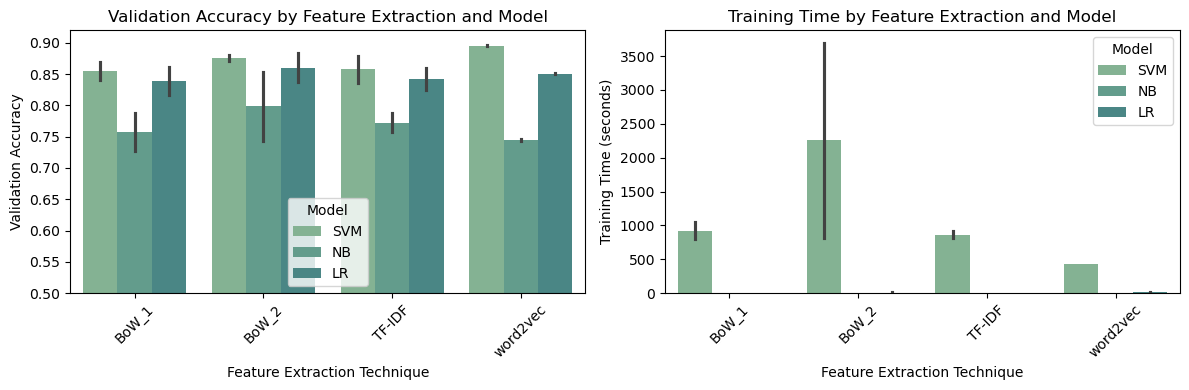

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# First subplot: Validation Accuracy
sns.barplot(data=results_df, x='feature_extraction', y='val_score', hue='model', ax=axes[0])
axes[0].set_title('Validation Accuracy by Feature Extraction and Model')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_xlabel('Feature Extraction Technique')
axes[0].set_ylim(0.5, 0.92)
axes[0].tick_params(axis='x', rotation=45) 
axes[0].legend(title='Model')

# Second subplot: Training Time
sns.barplot(data=results_df, x='feature_extraction', y='training_time', hue='model', ax=axes[1]) 
axes[1].set_title('Training Time by Feature Extraction and Model')
axes[1].set_ylabel('Training Time (seconds)')
axes[1].set_xlabel('Feature Extraction Technique')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Model')

plt.savefig('results/plots/val_train_by_feature_model.png')
plt.tight_layout() 
plt.show()

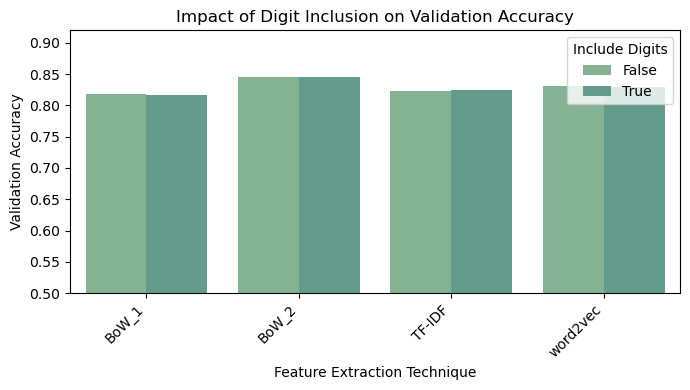

In [30]:
plt.figure(figsize=(7, 4))
sns.barplot(data=results_df, x='feature_extraction', y='val_score', hue='include_digits', errorbar=None)
plt.title('Impact of Digit Inclusion on Validation Accuracy')
plt.ylabel('Validation Accuracy')
plt.xlabel('Feature Extraction Technique')
plt.ylim(0.5, 0.92)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Include Digits')
plt.tight_layout()
plt.savefig('results/plots/val_by_feature_digits.png')
plt.show()

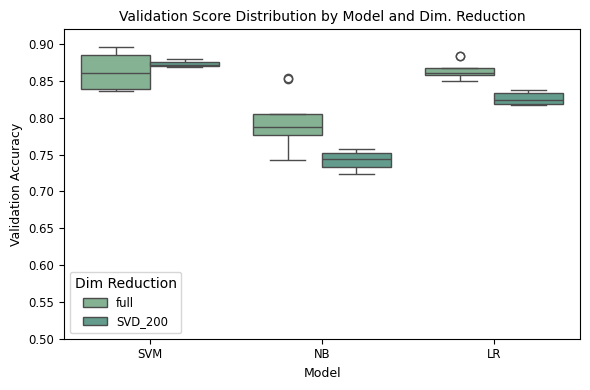

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4)) 

# Boxplot - Validation Score Distribution by Model
sns.boxplot(data=results_df, x='model', y='val_score', hue='dim', ax=ax)
ax.set_title('Validation Score Distribution by Model and Dim. Reduction', fontsize=10)
ax.set_ylabel('Validation Accuracy', fontsize=9) 
ax.set_xlabel('Model', fontsize=9) 
ax.set_ylim(0.5, 0.92)
ax.legend(title='Dim Reduction', fontsize='small') 
ax.tick_params(axis='both', labelsize='small')

plt.tight_layout()
plt.savefig('results/plots/validation_analysis.png')
plt.show()

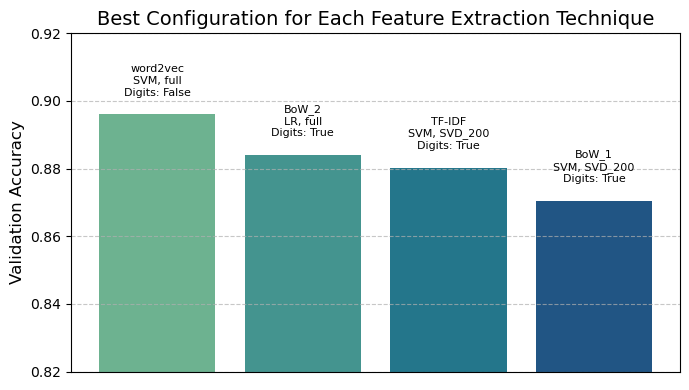

In [ ]:
best_configs = results_df.loc[results_df.groupby('feature_extraction')['val_score'].idxmax()]
best_configs = best_configs.sort_values('val_score', ascending=False)

plt.figure(figsize=(7, 4))
bars = plt.bar(
    range(len(best_configs)), 
    best_configs['val_score'], 
    color=sns.color_palette('crest', len(best_configs))
)

for i, bar in enumerate(bars):
    config = best_configs.iloc[i]
    label = f"{config['feature_extraction']}\n{config['model']}, {config['dim']}\nDigits: {config['include_digits']}"
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 0.005, 
        label,
        ha='center', va='bottom',
        fontsize=8, rotation=0
    )

plt.title('Best Configuration for Each Feature Extraction Technique', fontsize=14)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.xticks([])  
plt.ylim(0.82, 0.92)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('results/plots/best_configs.png', dpi=300)
plt.show()


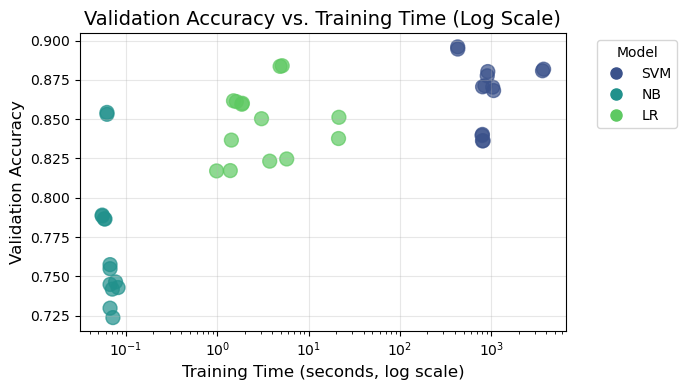

In [33]:
unique_models = results_df['model'].unique()
palette = sns.color_palette('viridis', len(unique_models))
model_colors = dict(zip(unique_models, palette))

colors = results_df['model'].map(model_colors)

plt.figure(figsize=(7, 4))
scatter = plt.scatter(
    results_df['training_time'], 
    results_df['val_score'],
    c=colors,
    s=100,
    alpha=0.7
)

handles = [plt.Line2D([0], [0], marker='o', color=model_colors[m], linestyle='', markersize=8) for m in unique_models]
plt.legend(handles, unique_models, title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xscale('log')
plt.title('Validation Accuracy vs. Training Time (Log Scale)', fontsize=14)
plt.xlabel('Training Time (seconds, log scale)', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/plots/accuracy_vs_time.png', dpi=300)
plt.show()